In [36]:
import xarray as xr
from math import nan
import matplotlib.pyplot as plt
import numpy as np

### Read in the data

In [37]:
dat = xr.open_dataset("/glade/p/cesm/cseg/inputdata/atm/cam/ozone_strataero/"
                      +"ozone_strataero_WACCM_L70_zm5day_18500101-20150103_CMIP6ensAvg_c180923.nc")

In [38]:
print(dat['O3'].attrs)

{'mdims': 1, 'units': 'mol/mol', 'long_name': 'O3 concentration', 'cell_methods': 'time: mean lon: mean'}


### Grab out the tropopause probabilities

In [39]:
tpause = dat.NITROP_PD

### Calculate the cumulative sum of probabilities from the top to bottom

In [40]:
tpausecumsum  = np.cumsum(tpause, axis=1)

### Generate a mask that is 1 above the tropopause, 0 below.  Topopause defined as where 95% likelihood tropopause is above that level

In [41]:
mask = xr.where(tpausecumsum >= 0.95, 0, 1)

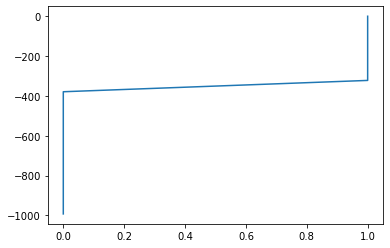

In [42]:
plt.plot(mask.isel(time=20, lat=20), -1.*dat.lev)

### Plot a single profile before masking

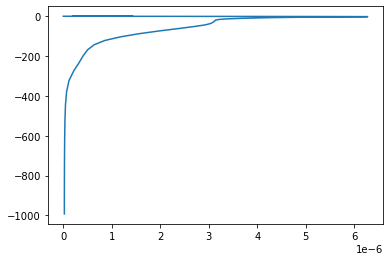

In [44]:
plt.plot(dat.O3.isel(time=20, lat=20), -1.*dat.lev)

### Multiply the ozone by this mask

In [45]:
dat['O3'] = dat.O3*np.array(mask)

### Plot the same profile after masking the tropause

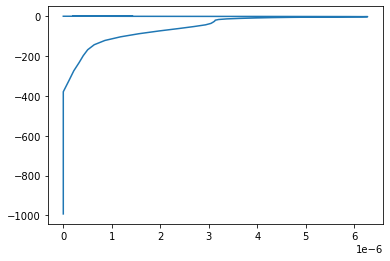

In [46]:
plt.plot(dat.O3.isel(time=20, lat=20), -1.*dat.lev)

### Retain original array attributes 

In [47]:
xr.set_options(keep_attrs=True)

### Now add new attributes

In [48]:
dat['O3'].attrs['history']="Tropospheric ozone set to zero for CMIP6-DAMIP Tier 2 stratospheric ozone experiments (DAMIP-histSOZ,DAMIP-ssp245SOZ)"

In [49]:
dat['O3'].attrs['script']="makeozone.ipynb"

In [50]:
dat['O3'].attrs['author']="islas,nanr,mmills"

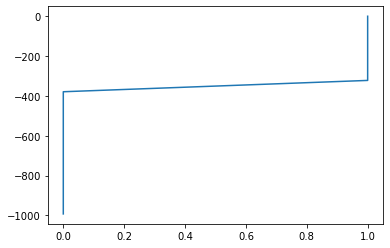

In [51]:
plt.plot(mask.isel(time=10, lat=20), -1.*mask.lev)

In [52]:
print(dat['O3'].attrs)

{'mdims': 1, 'units': 'mol/mol', 'long_name': 'O3 concentration', 'cell_methods': 'time: mean lon: mean', 'history': 'Tropospheric ozone set to zero for CMIP6-DAMIP Tier 2 stratospheric ozone experiments (DAMIP-histSOZ,DAMIP-ssp245SOZ)', 'script': 'makeozone.ipynb', 'author': 'islas,nanr,mmills'}


In [55]:
dat.attrs['RevisionHistory']='Tropospheric ozone set to zero for CMIP6-DAMIP Tier 2 stratospheric ozone experiments (DAMIP-histSOZ,DAMIP-ssp245SOZ)'
dat.attrs['RevisionScript']='makeozone.ipynb'
dat.attrs['RevisionAuthors']='islas,nanr,mmills'
dat.attrs['RevisionCheck']='mmills'
dat.attrs['RevisionDate']='8sep2021'

In [56]:
dat.to_netcdf("/glade/scratch/nanr/ozone_strataero_WACCM_L70_zm5day_18500101-20150103_CMIP6ensAvg_noTropoO3.c210908.nc")